# AS2: Transformer 文本分類 (AG News)
========================================

在本次作業中，你將使用 PyTorch 提供的 Transformer 模組，
組裝一個 Transformer Encoder 模型來進行新聞文本分類任務。

資料集: [AG News](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset) (4 類: World, Sports, Business, Sci/Tech)


===== 可使用的 PyTorch 零件 =====

| 模組                           | 用途                                      |
|-------------------------------|------------------------------------------|
| nn.Embedding                  | 將 token ID 轉換為稠密向量                   |
| nn.TransformerEncoderLayer    | 單層 Transformer Encoder (含 Self-Attention + FFN) |
| nn.TransformerEncoder         | 堆疊多層 TransformerEncoderLayer            |
| nn.Linear                     | 全連接層，用於最終分類                         |
| nn.Dropout                    | Dropout 正則化                              |
| nn.LayerNorm                  | Layer Normalization                       |

In [20]:
import torch
import math
import time
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

## 超參數區

In [21]:
# ============================================================
# 超參數設定 (你可以在實驗中調整這些數值)
#參數改動的部份我有問ChatGPT推薦要怎麼調整參數
# ============================================================
SEED = 42                #1.42
BATCH_SIZE = 64             #1.64
TEST_BATCH_SIZE = 128          #1.128
MAX_SEQ_LEN = 128            #1.128
EMBED_DIM = 256             #1.128.3.256
NUM_HEADS = 8              #1.4 2.4 3.8
NUM_LAYERS = 2              #1.2 2.3 3.2
FFN_DIM = 512              #1.256 2.256 3.512
DROPOUT = 0.2              #1.0.1 2.0.1 3.0.2
LEARNING_RATE = 5e-4          #1.1e-3 2.5e-4 3.5e-4
NUM_EPOCHS = 6              #1.5 2.6 3.6
NUM_CLASSES = 4             #1.4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cuda


## 資料集
請先至[此連結](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset)下載資料集後，將檔案上傳至 Colab

In [22]:
#從kaggle下載資料集
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Path to dataset files: /kaggle/input/ag-news-classification-dataset


In [23]:
# ============================================================
# (DO NOT MODIFY)
# ============================================================

!unzip train.csv.zip
!unzip test.csv.zip

unzip:  cannot find or open train.csv.zip, train.csv.zip.zip or train.csv.zip.ZIP.
unzip:  cannot find or open test.csv.zip, test.csv.zip.zip or test.csv.zip.ZIP.


### TODO1: 完成前處理資料集

In [24]:
def preprocess_agnews(
    filename: str,
    use_agnews_title: bool = False,
    train_size: float = 0.8,
    random_state: int = 42,
):
    # Read data
    df = pd.read_csv(filename)

    title_col = "Title"
    desc_col = "Description"

    # label 轉為 0-indexed
    df["new_label"] = df["Class Index"] - 1

    if "train" in filename:
        # 先使用 train_test_split 來切分資料集
        train_df, val_df = train_test_split(
            df, train_size=train_size, random_state=random_state
        )

        train_label = train_df["new_label"].tolist()
        val_label = val_df["new_label"].tolist()

        if use_agnews_title:
            train_text =(train_df[title_col].astype(str) + " " + train_df[desc_col].astype(str))
            # Write your code here
            val_text =(val_df[title_col].astype(str) + " " + val_df[desc_col].astype(str))
            # Write your code here
            train_text = train_text.tolist()
            val_text = val_text.tolist()
        else:
            train_text =train_df[desc_col].astype(str).tolist() # Write your code here
            val_text =val_df[desc_col].astype(str).tolist() # Write your code here

        return train_text, train_label, val_text, val_label

    else:
        test_label = df["new_label"].tolist()
        if use_agnews_title:
            test_text =df[title_col].astype(str) + " " + df[desc_col].astype(str) # Write your code here
            test_text = test_text.tolist()
        else:
            test_text =df[desc_col].astype(str).tolist() # Write your code here

        return test_text, test_label

In [25]:
test_text, test_label = preprocess_agnews(
    "test.csv",
    use_agnews_title=True,
)
train_text, train_label, val_text, val_label = preprocess_agnews(
    "train.csv",
    use_agnews_title=True,
)

In [26]:
class AGNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx]) for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

### Tokenizer
#### 對單一句子進行編碼

```python
output = tokenizer("Hello, how are you?")
print(output)
# {
#   'input_ids':      [101, 7592, 1010, 2129, 2024, 2017, 1029, 102],
#   'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0],
#   'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]
# }
```

#### 對多個句子進行批次編碼

```python
texts = ["I love NLP.", "Transformers are powerful."]
output = tokenizer(texts)
```

#### 常用參數詳解

| 參數 | 可選值 | 說明 |
|---|---|---|
| `truncation` | `True` / `False` | 是否截斷超過 `max_length` 的序列 |
| `padding` | `True` / `"max_length"` / `False` | `True`：pad 到 batch 最長；`"max_length"`：pad 到指定長度；`False`：不 pad |
| `max_length` | 整數 | 最大允許長度（含特殊 token） |
| `return_tensors` | `"pt"` / `"np"` / `None` | 回傳格式：PyTorch tensor / NumPy array / Python list |

In [27]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_text,
    truncation=True,
    padding=False, # 靜態:True 或 動態:False 須搭配 TODO2
    max_length=MAX_SEQ_LEN,
)
val_encodings = tokenizer(
    val_text,
    truncation=True,
    padding=False, # True 或 False 須搭配 TODO2
    max_length=MAX_SEQ_LEN,
)
test_encodings = tokenizer(
    test_text,
    truncation=True,
    padding=False, # True 或 False 須搭配 TODO2
    max_length=MAX_SEQ_LEN,
)

In [28]:
# 建立 Dataset variables

train_dataset = AGNewsDataset(train_encodings, train_label)
val_dataset = AGNewsDataset(val_encodings, val_label)
test_dataset = AGNewsDataset(test_encodings, test_label)

print(f"Train: {len(train_dataset)} samples, Test: {len(test_dataset)} samples")

Train: 96000 samples, Test: 7600 samples


### TODO2: 動態 padding

In [29]:
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    """動態填充：每個 batch 只 pad 到該 batch 內最長的序列長度。"""
    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item["attention_mask"] for item in batch]
    labels = torch.stack([item["labels"] for item in batch])

    # Write your code here
    padded_input_ids = pad_sequence(
        input_ids,
        batch_first=True,
        padding_value=0
    )

    padded_attention_mask = pad_sequence(
        attention_mask,
        batch_first=True,
        padding_value=0
    )
    return {
        "input_ids": padded_input_ids,
        "attention_mask": padded_attention_mask,
        "labels": labels,
    }

In [30]:
# 建立 DataLoader

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset, batch_size=TEST_BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset, batch_size=TEST_BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn,
)

In [31]:
# Positional Encoding (定義 class)

class PositionalEncoding(torch.nn.Module):
    r"""Inject some information about the relative or absolute position of the tokens
        in the sequence. The positional encodings have the same dimension as
        the embeddings, so that the two can be summed. Here, we use sine and cosine
        functions of different frequencies.

    Args:
        d_model: the embed dim (required).
        dropout: the dropout value (default=0.1).
        max_len: the max. length of the incoming sequence (default=5000).
    Examples:
        >>> pos_encoder = PositionalEncoding(d_model)
    """

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = torch.nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model) ← 轉為 batch_first
        self.register_buffer('pe', pe)

    def forward(self, x):
        r"""Inputs of forward function
        Args:
            x: the sequence fed to the positional encoder model (required).
        Shape:
            x: [sequence length, batch size, embed dim]
            output: [sequence length, batch size, embed dim]
        Examples:
            >>> output = pos_encoder(x)
        """
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        # x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

## Model

### TODO3 & TODO4
- TODO3: 完成 Transformer Encoder
- TODO4: 完成模型前向傳播流程

In [32]:
class TransformerClassifier(torch.nn.Module):
    """基於 Transformer Encoder 的文本分類模型
    """
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 ffn_dim, num_classes, max_len, dropout=0.1):
        super().__init__()

        self.embedding = torch.nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim, dropout, max_len)

        self.encoder_layer =torch.nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True
        ) # Write your code here

        self.transformer_encoder = torch.nn.TransformerEncoder(
            self.encoder_layer,
            num_layers,
        )
        self.classifier = torch.nn.Linear(embed_dim, num_classes)
        self.dropout = torch.nn.Dropout(dropout)

        self.embed_dim = embed_dim

    def forward(self, input_ids, attention_mask):
        """
        Args:
            input_ids:      (batch_size, seq_len) 輸入的 token ID
            attention_mask: (batch_size, seq_len) 1 表示有效 token，0 表示 padding

        Returns:
            logits: (batch_size, num_classes) 各類別的預測分數 (未經 softmax)
        """
        # Step 1: Embedding
        x = self.embedding(input_ids)

        # Step 2: Scaling (通常我們會對 embeddings 乘上 d_model 的平方根)
        x = x * math.sqrt(self.embed_dim)# Write your code here

        # Step 3: Positional Encoding
        x = self.pos_encoder(x) # Write your code here

        # Step 4: Padding Mask
        src_key_padding_mask = (attention_mask == 0)

        # Step 5: Transformer Encoder
        encoder_output = self.transformer_encoder(
            src=x,
            src_key_padding_mask=src_key_padding_mask,
        )

        # Step 6: Mean Pooling
        mask_expanded = attention_mask.unsqueeze(-1).float()
        sum_embeddings = (encoder_output * mask_expanded).sum(dim=1)
        sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
        pooled = sum_embeddings / sum_mask

        # Step 7: 分類
        logits = self.classifier(pooled) # Write your code here
        return logits

## 準備訓練

In [33]:
# 建立模型

model = TransformerClassifier(
    vocab_size=tokenizer.vocab_size,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ffn_dim=FFN_DIM,
    num_classes=NUM_CLASSES,
    max_len=MAX_SEQ_LEN,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print("=" * 60)

Model parameters: 9,395,972


In [34]:
# 定義損失函數與優化器

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [35]:
# ============================================================
# 評估函式 (DO NOT MODIFY)
# ============================================================
def evaluate(model, dataloader, device):
    """計算模型在給定資料集上的準確率"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            predictions = torch.argmax(logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total

## 開始訓練

### TODO5: 完成模型訓練步驟

In [36]:
# 訓練迴圈

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    num_batches = 0
    start_time = time.time()

    for batch in tqdm(train_loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        # TODO 5: 完成訓練迴圈的步驟
        # Write your code here
        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    # --- 每個 epoch 結束後的評估 (DO NOT MODIFY) ---
    avg_loss = total_loss / num_batches
    elapsed = time.time() - start_time
    print("Start evaluating the model on the training set.")
    train_acc = evaluate(model, train_loader, DEVICE)
    print("Start evaluating the model on the validation set.")
    val_acc = evaluate(model, val_loader, DEVICE)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Validation Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

print("=" * 60)
print("Training complete!")
final_acc = evaluate(model, test_loader, DEVICE)
print(f"Final Test Accuracy: {final_acc:.4f}")

100%|██████████| 1500/1500 [00:53<00:00, 28.23it/s]


Start evaluating the model on the training set.


100%|██████████| 1500/1500 [00:14<00:00, 106.29it/s]


Start evaluating the model on the validation set.


100%|██████████| 188/188 [00:02<00:00, 75.52it/s]


...

Start evaluating the model on the validation set.


100%|██████████| 188/188 [00:02<00:00, 73.91it/s]


Epoch [6/6] Loss: 0.2607 | Train Acc: 0.9297 | Validation Acc: 0.9090 | Time: 51.8s
Training complete!


100%|██████████| 60/60 [00:00<00:00, 76.77it/s]

Final Test Accuracy: 0.9051


### TODO6: 繪製 Confusion Matrix（使用 Claude Code）

在此 TODO 中，你必須使用 **Claude Code（終端機版本）** 來協助你完成
Confusion Matrix 的繪製。請勿使用 claude.ai 網頁版。

> ⚠️ 本題要求每位同學獨立使用 Claude Code 完成，
> 助教將檢查你的報告內容是否具有個人獨特性。

**步驟：**

#### Step 1: 在 Colab 上匯出推論結果

在 Colab 完成模型訓練與推論後，將 test set 的預測結果與真實標籤儲存為檔案。
請將以下範例程式碼加在訓練完成後執行：
```python
# --- 匯出預測結果 (請在 Colab 上執行) ---
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"]

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=-1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

np.savez("test_predictions.npz", preds=all_preds, labels=all_labels)
print(f"已儲存 {len(all_preds)} 筆預測結果至 test_predictions.npz")
```

將產生的 `test_predictions.npz` 下載到你的本機電腦。

---

#### Step 2: 在本機使用 Claude Code 撰寫畫圖程式

1. 安裝 Claude Code（如尚未安裝）：`npm install -g @anthropic-ai/claude-code`
2. 在存放 `test_predictions.npz` 的目錄下啟動 Claude Code
3. 透過 Claude Code 完成一個 Python 腳本，讀取 `.npz` 檔案並繪製
   Confusion Matrix（須包含數值標籤，類別名稱為
   `["World", "Sports", "Business", "Sci/Tech"]`）
4. 在本機執行該腳本，將圖片儲存為 `confusion_matrix.png`

---

#### Step 3: 撰寫報告

請於報告中詳細說明以下項目：

1. **(2%) 你使用的 Claude Code 版本**（執行 `claude --version` 取得）
2. **(10%) 你的操作過程**：你給予 Claude Code 的提示詞、
   Claude Code 的回應摘要（複製貼上或截圖）、以及你進行了幾輪對話來完成
3. **(10%) 你如何驗證程式碼的正確性？** 請提出具體的驗證方法，例如：
   - 手動取一小組資料，預先計算預期的 confusion matrix 數值並比對
   - 確認矩陣每一列的加總等於該類別的實際樣本數
   - 人類檢查（可能你自己也用 sklearn 的 `ConfusionMatrixDisplay`寫一段畫圖程式碼），確定與 Claude 產生的結果相符

   **不接受**僅回答「我有看過/檢查過」。
4. **(3%) 於報告中附上最終的 `confusion_matrix.png` 圖片**

In [37]:
# --- 匯出預測結果 (請在 Colab 上執行) ---
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"]

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=-1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
#preds,labels
np.savez("test_predictions.npz", preds=all_preds, labels=all_labels)
print(f"已儲存 {len(all_preds)} 筆預測結果至 test_predictions.npz")

已儲存 7600 筆預測結果至 test_predictions.npz


Confusion Matrix (sklearn):
[[1651   63  113   73]
 [  12 1864   19    5]
 [  37   27 1638  198]
 [  32   27  115 1726]]


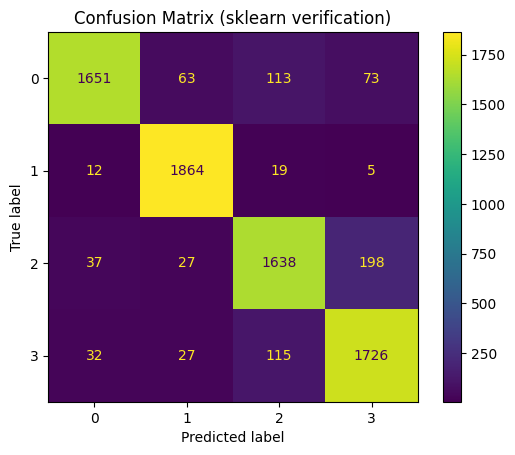

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

data = np.load("test_predictions.npz")
preds = data["preds"]
labels = data["labels"]

# sklearn 計算 confusion matrix
cm = confusion_matrix(labels, preds)

print("Confusion Matrix (sklearn):")
print(cm)

# 畫圖
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (sklearn verification)")
plt.savefig("confusion_matrix_sklearn.png")
plt.show()

In [39]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.4
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         